In [1]:
%pip install statsmodels wandb -Uq

import os
import getpass

import wandb

_wandb_api_key_env = os.environ.get("WANDB_API_KEY")
os.environ.pop("WANDB_API_KEY", None)
try:
    wandb.logout()
except Exception:
    pass

WANDB_ENTITY = "toberi23-free-university-of-tbilisi-"
WANDB_PROJECT = "Walmart-Recruiting-Store-Sales-Forecasting"

wandb_key = _wandb_api_key_env or getpass.getpass("Paste your W&B API key: ").strip()
wandb.login(key=wandb_key, relogin=True, force=True, verify=True)

who = wandb.Api().viewer
print("Logged in as:", who.username, "| entity:", who.entity)

Note: you may need to restart the kernel to use updated packages.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/macbookpro/.netrc
wandb: Currently logged in as: toberi23 (toberi23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged in as: toberi23 | entity: toberi23-free-university-of-tbilisi-


In [2]:
import os, time, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from statsmodels.tsa.statespace.sarimax import SARIMAX

import wandb

SEED = 42
np.random.seed(SEED)

MODEL_TAG = "SARIMA"
WANDB_GROUP = "SARIMA_Training"
pd.set_option("display.width", 200)

In [3]:
_LOCAL_DATA_DIR = os.path.join("data", "walmart-recruiting-store-sales-forecasting")
_KAGGLE_DATA_DIR = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"

COMP = (
    os.environ.get("WALMART_DATA_DIR")
    or (_LOCAL_DATA_DIR if os.path.isdir(_LOCAL_DATA_DIR) else _KAGGLE_DATA_DIR)
)
print("Reading competition data from:", COMP)

def load_merged(kind: str = "train") -> pd.DataFrame:
    if kind not in ("train", "test"):
        raise ValueError("kind must be 'train' or 'test'")
    base = pd.read_csv(f"{COMP}/{kind}.csv.zip")
    base["Date"] = pd.to_datetime(base["Date"])
    stores = pd.read_csv(f"{COMP}/stores.csv")
    feats = pd.read_csv(f"{COMP}/features.csv.zip")
    feats["Date"] = pd.to_datetime(feats["Date"])
    feats = feats.drop(columns=["IsHoliday"])
    return (
        base.merge(stores, on="Store", how="left")
            .merge(feats, on=["Store", "Date"], how="left")
            .sort_values(["Store", "Dept", "Date"])
            .reset_index(drop=True)
    )

df_train = load_merged("train")
df_test = load_merged("test")
print("Train:", df_train.shape, "| Test:", df_test.shape)
df_train.head()

Reading competition data from: data/walmart-recruiting-store-sales-forecasting
Train: (421570, 16) | Test: (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [4]:
def wmae(y_true, y_pred, is_holiday):
    w = np.where(np.asarray(is_holiday, dtype=bool), 5.0, 1.0)
    return float(np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w))

assert abs(wmae([10, 20], [8, 15], [True, False]) - 15 / 6) < 1e-9

VAL_START = pd.Timestamp("2011-11-04")
VAL_END = pd.Timestamp("2012-07-27")

cv_train = df_train[df_train.Date < VAL_START].copy()
cv_val = df_train[(df_train.Date >= VAL_START) & (df_train.Date <= VAL_END)].copy()

print("CV train:", cv_train.shape, cv_train.Date.min().date(), "->", cv_train.Date.max().date())
print("CV val  :", cv_val.shape, cv_val.Date.min().date(), "->", cv_val.Date.max().date())
print("Val holiday weeks:", cv_val.loc[cv_val.IsHoliday, "Date"].dt.strftime("%Y-%m-%d").unique().tolist())

CV train: (267184, 16) 2010-02-05 -> 2011-10-28
CV val  : (115856, 16) 2011-11-04 -> 2012-07-27
Val holiday weeks: ['2011-11-25', '2011-12-30', '2012-02-10']


In [5]:
MARKDOWN_COLS = [f"MarkDown{i}" for i in range(1, 6)]
MEDIAN_FILL_COLS = ["CPI", "Unemployment", "Temperature", "Fuel_Price"]

class DataCleaner(BaseEstimator, TransformerMixin):

    def __init__(self, markdown_cols=None, median_cols=None):
        self.markdown_cols = markdown_cols if markdown_cols is not None else MARKDOWN_COLS
        self.median_cols = median_cols if median_cols is not None else MEDIAN_FILL_COLS

    def fit(self, X, y=None):
        self.medians_ = {c: X[c].median() for c in self.median_cols}
        return self

    def transform(self, X):
        X = X.copy()
        X[self.markdown_cols] = X[self.markdown_cols].fillna(0.0)
        for c in self.median_cols:
            X[c] = X[c].fillna(self.medians_[c])
        return X

run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, group=WANDB_GROUP, name=f"{MODEL_TAG}_Data_Cleaning",
                  job_type="data-cleaning", tags=[MODEL_TAG, "data-cleaning"])

cleaner = DataCleaner()
cleaner.fit(cv_train)

cv_train_clean = cleaner.transform(cv_train)
cv_val_clean = cleaner.transform(cv_val)

missing_report = cv_train_clean[cleaner.markdown_cols + cleaner.median_cols].isna().mean()
print("Learned fill medians:", cleaner.medians_)
print("\nRemaining missing % after cleaning:\n", missing_report)

wandb.config.update({"markdown_fill": 0, **{f"median_{c}": v for c, v in cleaner.medians_.items()}})
wandb.log({"post_clean_missing_pct_total": float(missing_report.sum())})
run.finish()

Learned fill medians: {'CPI': np.float64(182.0774691), 'Unemployment': np.float64(8.099), 'Temperature': np.float64(62.97), 'Fuel_Price': np.float64(3.046)}

Remaining missing % after cleaning:
 MarkDown1       0.0
MarkDown2       0.0
MarkDown3       0.0
MarkDown4       0.0
MarkDown5       0.0
CPI             0.0
Unemployment    0.0
Temperature     0.0
Fuel_Price      0.0
dtype: float64


post_clean_missing_pct_total,▁
post_clean_missing_pct_total,0


In [6]:
def _holiday_dates():
    return {
        "SuperBowl":   ["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"],
        "LaborDay":    ["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"],
        "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"],
        "Christmas":    ["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"],
    }

class HolidayExogBuilder(BaseEstimator, TransformerMixin):

    def __init__(self, lower_window=-3, upper_window=1):
        self.lower_window = lower_window
        self.upper_window = upper_window

    def fit(self, X=None, y=None):
        windows = {}
        for name, dates in _holiday_dates().items():
            days = set()
            for d in dates:
                anchor = pd.Timestamp(d)
                for offset in range(self.lower_window, self.upper_window + 1):
                    days.add(anchor + pd.Timedelta(days=offset))
            windows[name] = days
        self.holiday_windows_ = windows
        self.holiday_cols_ = [f"holiday_{name.lower()}" for name in windows]
        return self

    def transform(self, X):
        X = X.copy()
        for name, days in self.holiday_windows_.items():
            X[f"holiday_{name.lower()}"] = X["Date"].isin(days).astype(int)
        return X

run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, group=WANDB_GROUP, name=f"{MODEL_TAG}_Feature_Engineering",
                  job_type="feature-engineering", tags=[MODEL_TAG, "feature-engineering"],
                  config={"holiday_window": [-3, 1]})

engineer = HolidayExogBuilder(lower_window=-3, upper_window=1)
engineer.fit()
cv_train_fe = engineer.transform(cv_train_clean)
print("Engineered holiday columns:", engineer.holiday_cols_)
print(cv_train_fe[["Date"] + engineer.holiday_cols_].loc[cv_train_fe[engineer.holiday_cols_].sum(axis=1) > 0].drop_duplicates("Date").head(10))

wandb.log({"n_holiday_cols": len(engineer.holiday_cols_)})
run.finish()

Engineered holiday columns: ['holiday_superbowl', 'holiday_laborday', 'holiday_thanksgiving', 'holiday_christmas']
         Date  holiday_superbowl  holiday_laborday  holiday_thanksgiving  holiday_christmas
1  2010-02-12                  1                 0                     0                  0
31 2010-09-10                  0                 1                     0                  0
42 2010-11-26                  0                 0                     1                  0
47 2010-12-31                  0                 0                     0                  1
53 2011-02-11                  1                 0                     0                  0
83 2011-09-09                  0                 1                     0                  0


n_holiday_cols,▁
n_holiday_cols,4


In [7]:
CANDIDATE_REGRESSOR_COLS = ["IsHoliday"] + engineer.holiday_cols_ + MARKDOWN_COLS + ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
STRUCTURALLY_EXCLUDED_COLS = list(MARKDOWN_COLS)

class RegressorSelector(BaseEstimator, TransformerMixin):

    def __init__(self, candidate_cols=None, structurally_excluded=None):
        self.candidate_cols = candidate_cols if candidate_cols is not None else CANDIDATE_REGRESSOR_COLS
        self.structurally_excluded = structurally_excluded if structurally_excluded is not None else STRUCTURALLY_EXCLUDED_COLS

    def fit(self, X, y=None):
        target = y if y is not None else X["Weekly_Sales"]
        corr_frame = X[self.candidate_cols].copy()
        if "IsHoliday" in corr_frame.columns:
            corr_frame["IsHoliday"] = corr_frame["IsHoliday"].astype(int)
        self.correlations_ = corr_frame.corrwith(target).abs().sort_values(ascending=False)
        self.selected_regressors_ = [c for c in self.candidate_cols if c not in self.structurally_excluded]
        return self

    def transform(self, X):
        key_cols = [c for c in ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"] if c in X.columns]
        keep = key_cols + [c for c in self.selected_regressors_ if c not in key_cols]
        return X[keep]

run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, group=WANDB_GROUP, name=f"{MODEL_TAG}_Feature_Selection",
                  job_type="feature-selection", tags=[MODEL_TAG, "feature-selection"])

selector = RegressorSelector()
selector.fit(cv_train_fe)

print("Train-only |correlation| with Weekly_Sales:\n", selector.correlations_)
print("\nSelected regressors:", selector.selected_regressors_)
print("Dropped regressors (structurally excluded):", selector.structurally_excluded)

wandb.log({
    "n_candidate_regressors": len(selector.candidate_cols),
    "n_selected_regressors": len(selector.selected_regressors_),
    **{f"corr_{c}": float(selector.correlations_.get(c, np.nan)) for c in selector.candidate_cols},
})
run.finish()

Train-only |correlation| with Weekly_Sales:
 holiday_thanksgiving    0.030773
CPI                     0.022598
Unemployment            0.021444
holiday_christmas       0.010016
IsHoliday               0.009405
holiday_superbowl       0.002463
holiday_laborday        0.001281
Temperature             0.000785
Fuel_Price              0.000231
MarkDown1                    NaN
MarkDown2                    NaN
MarkDown3                    NaN
MarkDown4                    NaN
MarkDown5                    NaN
dtype: float64

Selected regressors: ['IsHoliday', 'holiday_superbowl', 'holiday_laborday', 'holiday_thanksgiving', 'holiday_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
Dropped regressors (structurally excluded): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']


corr_CPI,▁
corr_Fuel_Price,▁
corr_IsHoliday,▁
corr_Temperature,▁
corr_Unemployment,▁
corr_holiday_christmas,▁
corr_holiday_laborday,▁
corr_holiday_superbowl,▁
corr_holiday_thanksgiving,▁
n_candidate_regressors,▁
+6,...


   d  adf_statistic   p_value  stationary
0  0      -4.758862  0.000065        True

Recommended differencing order d = 0 (first d where ADF p-value < 0.05, i.e. we can reject the unit-root null)


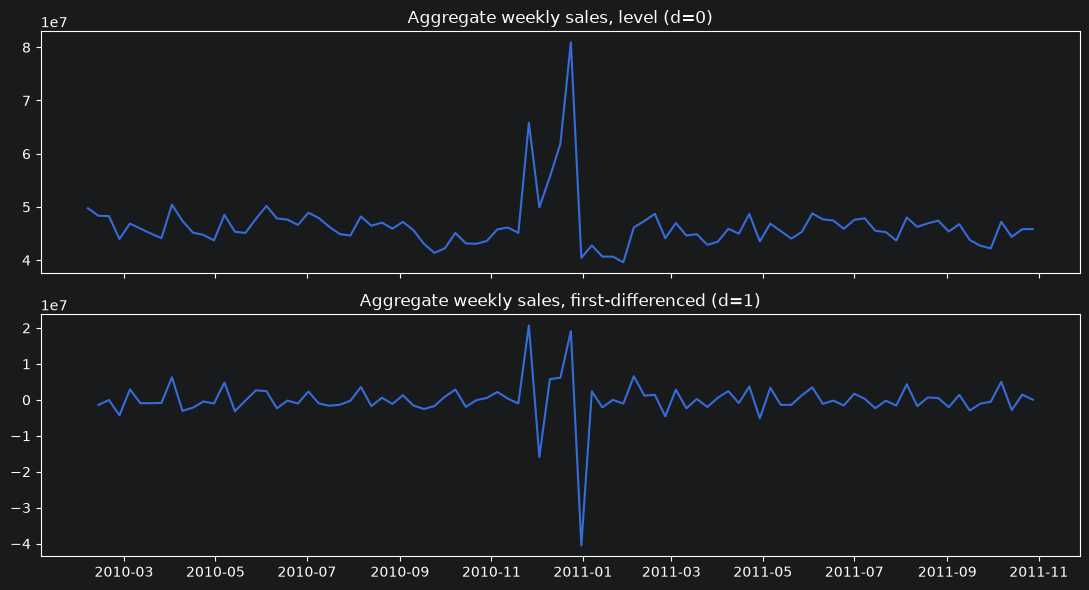

adf_pvalue_d0,▁
recommended_d,▁
adf_pvalue_d0,7e-05
recommended_d,0


In [8]:
from statsmodels.tsa.stattools import adfuller

class StationarityAnalyzer:

    def __init__(self, max_d=2, alpha=0.05):
        self.max_d = max_d
        self.alpha = alpha

    def fit(self, series):
        s = series.dropna().copy()
        self.results_ = []
        for d in range(self.max_d + 1):
            stat, pvalue, *_ = adfuller(s, autolag="AIC")
            self.results_.append({"d": d, "adf_statistic": stat, "p_value": pvalue, "stationary": pvalue < self.alpha})
            if pvalue < self.alpha:
                break
            s = s.diff().dropna()
        self.recommended_d_ = next((r["d"] for r in self.results_ if r["stationary"]), self.max_d)
        return self

    def summary(self):
        return pd.DataFrame(self.results_)

run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, group=WANDB_GROUP, name=f"{MODEL_TAG}_Stationarity_Analysis",
                  job_type="stationarity-analysis", tags=[MODEL_TAG, "stationarity", "adf-test"])

weekly_total = cv_train.groupby("Date")["Weekly_Sales"].sum().sort_index()
analyzer = StationarityAnalyzer(max_d=2).fit(weekly_total)
adf_summary = analyzer.summary()
print(adf_summary)
print(f"\nRecommended differencing order d = {analyzer.recommended_d_} "
      f"(first d where ADF p-value < 0.05, i.e. we can reject the unit-root null)")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(weekly_total.index, weekly_total.values)
axes[0].set_title("Aggregate weekly sales, level (d=0)")
axes[1].plot(weekly_total.index, weekly_total.diff().values)
axes[1].set_title("Aggregate weekly sales, first-differenced (d=1)")
plt.tight_layout()
plt.show()

wandb.log({"recommended_d": int(analyzer.recommended_d_),
           **{f"adf_pvalue_d{r['d']}": r["p_value"] for r in analyzer.results_}})
wandb.log({"adf_summary": wandb.Table(dataframe=adf_summary)})
run.finish()

/Users/macbookpro/PycharmProjects/machine_learning_final_project/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


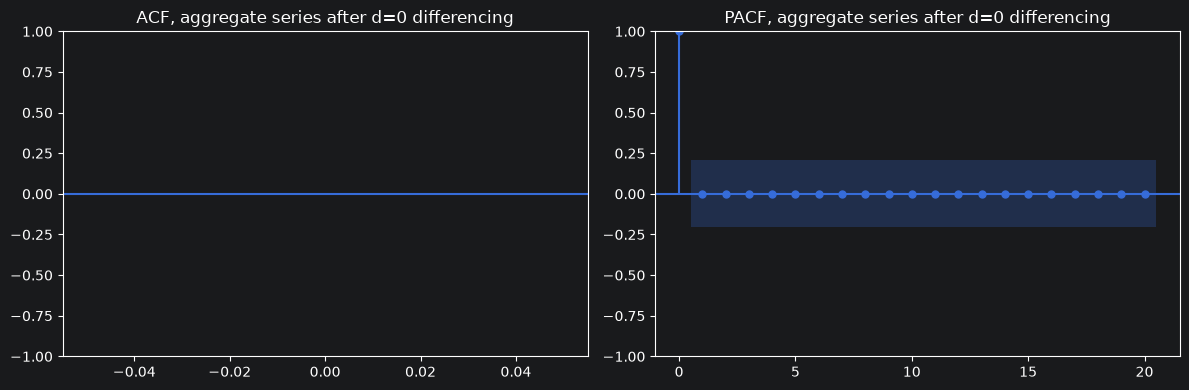

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diffed = weekly_total.diff(analyzer.recommended_d_).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diffed, lags=20, ax=axes[0])
axes[0].set_title(f"ACF, aggregate series after d={analyzer.recommended_d_} differencing")
plot_pacf(diffed, lags=20, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF, aggregate series after d={analyzer.recommended_d_} differencing")
plt.tight_layout()
plt.show()

ACF at lag 52 (one year), after d=0 non-seasonal differencing: nan
A value clearly outside the usual +-2/sqrt(N) significance band indicates real yearly 
autocorrelation remains after ordinary differencing -- i.e. exactly the pattern the seasonal 
(P, D, Q, m=52) terms below are meant to capture.


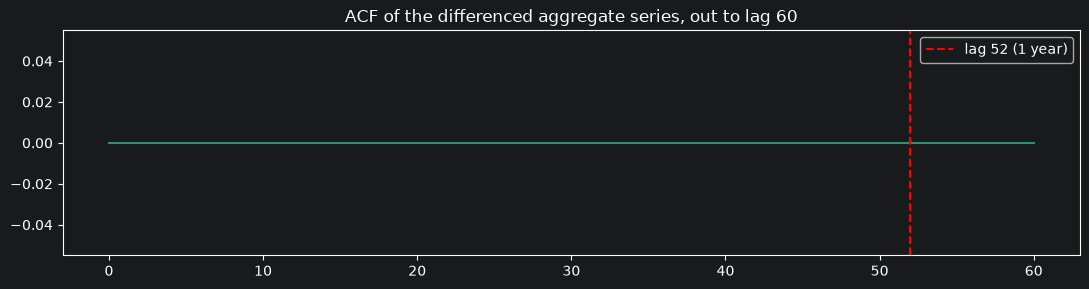

In [10]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(weekly_total.diff(analyzer.recommended_d_).dropna(), nlags=60)
lag52_acf = acf_vals[52] if len(acf_vals) > 52 else float("nan")
print(f"ACF at lag 52 (one year), after d={analyzer.recommended_d_} non-seasonal differencing: {lag52_acf:.3f}")
print("A value clearly outside the usual +-2/sqrt(N) significance band indicates real yearly ")
print("autocorrelation remains after ordinary differencing -- i.e. exactly the pattern the seasonal ")
print("(P, D, Q, m=52) terms below are meant to capture.")

fig, ax = plt.subplots(figsize=(11, 3))
ax.stem(range(len(acf_vals)), acf_vals)
ax.axvline(52, color="red", linestyle="--", label="lag 52 (1 year)")
ax.set_title("ACF of the differenced aggregate series, out to lag 60")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
SAMPLE_N = 50

series_mean = cv_train.groupby(["Store", "Dept"])["Weekly_Sales"].mean()
series_keys_all = cv_train[["Store", "Dept"]].drop_duplicates()
series_keys_all["quartile"] = pd.qcut(
    series_keys_all.apply(lambda r: series_mean[(r.Store, r.Dept)], axis=1), 4, labels=False, duplicates="drop"
)

sample_keys = (
    series_keys_all.groupby("quartile", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), SAMPLE_N // series_keys_all.quartile.nunique()), random_state=SEED))
    [["Store", "Dept"]]
    .reset_index(drop=True)
)
print("Sampled series:", len(sample_keys), "/", len(series_keys_all))
sample_keys.head()

Sampled series: 48 / 3254


,Store,Dept
0,17,59
1,37,24
2,16,49
3,20,77
4,35,78


In [12]:
MIN_HISTORY_WEEKS = 52

class SeasonalNaiveFallback:

    def __init__(self, min_history_weeks=MIN_HISTORY_WEEKS):
        self.min_history_weeks = min_history_weeks

    def is_needed(self, history_df):
        if len(history_df) == 0:
            return True
        n_hist = history_df["Date"].nunique()
        series_mean = history_df["Weekly_Sales"].mean()
        return n_hist < self.min_history_weeks or history_df["Weekly_Sales"].std() == 0 or np.isnan(series_mean)

    def predict(self, history_df, future_df, global_fallback_mean):
        series_mean = history_df["Weekly_Sales"].mean() if len(history_df) else global_fallback_mean
        fallback_value = series_mean if not np.isnan(series_mean) else global_fallback_mean

        lag = history_df[["Date", "Weekly_Sales"]].rename(columns={"Date": "lag_date", "Weekly_Sales": "snaive"})
        fd = future_df.copy()
        fd["lag_date"] = fd["Date"] - pd.Timedelta(weeks=52)
        fd = fd.merge(lag, on="lag_date", how="left")
        return fd["snaive"].fillna(fallback_value).values

In [13]:
CHRISTMAS_WEEK52_ANCHORS = {
    2010: pd.Timestamp("2010-12-31"),
    2011: pd.Timestamp("2011-12-30"),
    2012: pd.Timestamp("2012-12-28"),
}
TARGET_YEAR = 2012

class ChristmasWeekShiftAdjuster:

    def __init__(self, bulge_threshold=1.10, christmas_anchors=None, target_year=TARGET_YEAR):
        self.bulge_threshold = bulge_threshold
        self.christmas_anchors = christmas_anchors if christmas_anchors is not None else CHRISTMAS_WEEK52_ANCHORS
        self.target_year = target_year

    def fit(self, train_df):
        self.train_start_ = train_df.groupby(["Store", "Dept"])["Date"].min()
        self.dec_cutoffs_ = {year: anchor - pd.Timedelta(weeks=4) for year, anchor in self.christmas_anchors.items()}
        return self

    def adjust(self, X, preds):
        pred_df = X[["Store", "Dept", "Date"]].copy()
        pred_df["Weekly_Sales"] = preds
        pred_df["_row"] = np.arange(len(pred_df))

        adjusted = preds.copy()
        self.last_stats_ = {"n_bulge_departments": 0, "n_shifted_two_year": 0,
                             "n_shifted_one_year": 0, "total_abs_sales_shifted": 0.0}

        for year, anchor in self.christmas_anchors.items():
            if year != self.target_year:
                continue
            week_dates = {w: anchor - pd.Timedelta(weeks=52 - w) for w in [48, 49, 50, 51, 52]}
            week_lookup = {v: k for k, v in week_dates.items()}
            in_window = pred_df["Date"].isin(week_lookup)
            if not in_window.any():
                continue

            sub = pred_df.loc[in_window].copy()
            sub["week"] = sub["Date"].map(week_lookup)
            wide = sub.pivot_table(index=["Store", "Dept"], columns="week", values="Weekly_Sales")
            wide = wide.dropna(subset=[48, 49, 50, 51, 52])
            if wide.empty:
                continue

            avg_49_51 = wide[[49, 50, 51]].mean(axis=1)
            avg_48_52 = wide[[48, 52]].mean(axis=1)
            has_bulge = avg_49_51 >= self.bulge_threshold * avg_48_52

            train_start = self.train_start_.reindex(wide.index)
            has_two_years = train_start <= self.dec_cutoffs_.get(year - 1, pd.Timestamp.min)
            has_one_year = (train_start <= self.dec_cutoffs_.get(year, pd.Timestamp.min)) & (~has_two_years)

            shift_fraction = pd.Series(0.0, index=wide.index)
            shift_fraction[has_two_years] = 2.5 / 7
            shift_fraction[has_one_year] = 2.0 / 7
            shift_fraction[~has_bulge] = 0.0

            to_shift = shift_fraction[shift_fraction > 0].index
            if len(to_shift) == 0:
                continue

            shifted = wide.copy()
            for key in to_shift:
                vals = wide.loc[key, [48, 49, 50, 51, 52]].to_numpy(dtype=float)
                s = shift_fraction[key]
                shifted.loc[key] = [(1 - s) * vals[i] + s * vals[(i - 1) % 5] for i in range(5)]

            shifted_long = shifted.loc[to_shift].stack().rename("Weekly_Sales_shifted").reset_index()
            shifted_long["Date"] = shifted_long["week"].map(week_dates)
            merged = sub.merge(shifted_long[["Store", "Dept", "Date", "Weekly_Sales_shifted"]],
                                on=["Store", "Dept", "Date"], how="left")
            merged = merged.dropna(subset=["Weekly_Sales_shifted"])
            adjusted[merged["_row"].to_numpy()] = merged["Weekly_Sales_shifted"].to_numpy()

            delta_abs = (shifted.loc[to_shift] - wide.loc[to_shift]).abs().to_numpy().sum()
            self.last_stats_["n_bulge_departments"] += int(has_bulge.sum())
            self.last_stats_["n_shifted_two_year"] += int((shift_fraction == 2.5 / 7).sum())
            self.last_stats_["n_shifted_one_year"] += int((shift_fraction == 2.0 / 7).sum())
            self.last_stats_["total_abs_sales_shifted"] += float(delta_abs)

        return adjusted

In [14]:
SEASONAL_PERIOD = 52

FIT_EXCEPTION_LOG = {"n": 0}
MAX_FIT_EXCEPTIONS_TO_PRINT = 5

class SARIMASeriesModel(BaseEstimator, RegressorMixin):

    def __init__(self, p=1, d=1, q=1, P=0, D=1, Q=0, m=SEASONAL_PERIOD, trend="n",
                 use_regressors=True, regressor_cols=None, min_history_weeks=MIN_HISTORY_WEEKS):
        self.p, self.d, self.q = p, d, q
        self.P, self.D, self.Q, self.m = P, D, Q, m
        self.trend = trend
        self.use_regressors = use_regressors
        self.regressor_cols = regressor_cols or []
        self.min_history_weeks = min_history_weeks

    def fit(self, X, y=None):
        self.fallback_ = SeasonalNaiveFallback(self.min_history_weeks)
        self.history_ = X.sort_values("Date")
        self.needs_fallback_ = self.fallback_.is_needed(X)

        if not self.needs_fallback_:
            endog = self.history_["Weekly_Sales"].values
            exog = self.history_[self.regressor_cols].astype(float).values if (self.use_regressors and self.regressor_cols) else None
            try:
                fitted = SARIMAX(
                    endog, exog=exog, order=(self.p, self.d, self.q),
                    seasonal_order=(self.P, self.D, self.Q, self.m), trend=self.trend,
                    enforce_stationarity=False, enforce_invertibility=False,
                ).fit(disp=False, maxiter=50)
                self.params_ = fitted.params.copy()
            except Exception as e:
                FIT_EXCEPTION_LOG["n"] += 1
                if FIT_EXCEPTION_LOG["n"] <= MAX_FIT_EXCEPTIONS_TO_PRINT:
                    print(f"[SARIMASeriesModel] SARIMAX fit failed ({type(e).__name__}: {e}) -- "
                          f"falling back to seasonal-naive for this series.")
                    if FIT_EXCEPTION_LOG["n"] == MAX_FIT_EXCEPTIONS_TO_PRINT:
                        print(f"[SARIMASeriesModel] (suppressing further fit-failure messages -- "
                              f"if this keeps happening for most series, something is systematically "
                              f"wrong, not just a few pathological series; check FIT_EXCEPTION_LOG['n'] "
                              f"vs. the number of series evaluated.)")
                self.needs_fallback_ = True
        return self

    def predict(self, X, global_fallback_mean=0.0):
        if self.needs_fallback_:
            return self.fallback_.predict(self.history_, X, global_fallback_mean)

        future = X.sort_values("Date")
        hist_endog = self.history_["Weekly_Sales"].astype(float).values
        hist_exog = self.history_[self.regressor_cols].astype(float).values if (self.use_regressors and self.regressor_cols) else None
        model = SARIMAX(
            hist_endog, exog=hist_exog, order=(self.p, self.d, self.q),
            seasonal_order=(self.P, self.D, self.Q, self.m), trend=self.trend,
            enforce_stationarity=False, enforce_invertibility=False,
        )
        fitted = model.filter(self.params_)
        exog = future[self.regressor_cols].astype(float).values if (self.use_regressors and self.regressor_cols) else None
        forecast = fitted.get_forecast(steps=len(future), exog=exog)
        preds = pd.Series(forecast.predicted_mean, index=future.index).reindex(X.index)
        return preds.values

class SARIMAForecastPipeline(BaseEstimator, RegressorMixin):

    def __init__(self, p=1, d=1, q=1, P=0, D=1, Q=0, m=SEASONAL_PERIOD, trend="n", use_regressors=True,
                 min_history_weeks=MIN_HISTORY_WEEKS, holiday_window=(-3, 1),
                 use_christmas_shift=True, christmas_bulge_threshold=1.10):
        self.p, self.d, self.q = p, d, q
        self.P, self.D, self.Q, self.m = P, D, Q, m
        self.trend = trend
        self.use_regressors = use_regressors
        self.min_history_weeks = min_history_weeks
        self.holiday_window = holiday_window
        self.use_christmas_shift = use_christmas_shift
        self.christmas_bulge_threshold = christmas_bulge_threshold

    def fit(self, X, y=None):
        print(f"[SARIMAForecastPipeline] fit() starting on {len(X)} rows", flush=True)
        self.cleaner_ = DataCleaner().fit(X)
        X_clean = self.cleaner_.transform(X)
        print("[SARIMAForecastPipeline] DataCleaner done", flush=True)

        self.engineer_ = HolidayExogBuilder(*self.holiday_window).fit()
        X_fe = self.engineer_.transform(X_clean)
        print("[SARIMAForecastPipeline] HolidayExogBuilder done", flush=True)

        self.selector_ = RegressorSelector(candidate_cols=CANDIDATE_REGRESSOR_COLS).fit(X_fe)
        self.train_ = self.selector_.transform(X_fe)
        print("[SARIMAForecastPipeline] RegressorSelector done", flush=True)

        self.global_fallback_mean_ = self.train_["Weekly_Sales"].mean()

        self.series_models_ = {}
        n_series_total_ = self.train_.groupby(["Store", "Dept"]).ngroups
        for i, ((store, dept), history) in enumerate(self.train_.groupby(["Store", "Dept"]), start=1):
            series_model = self._make_series_model()
            series_model.fit(history.sort_values("Date"))
            self.series_models_[(store, dept)] = series_model
            if i % 25 == 0 or i == n_series_total_:
                print(f"[SARIMAForecastPipeline] fit {i}/{n_series_total_} series "
                      f"(Store={store}, Dept={dept})", flush=True)

        print("[SARIMAForecastPipeline] all series_models_ fit -- starting christmas shift adjuster",
              flush=True)
        if self.use_christmas_shift:
            self.christmas_adjuster_ = ChristmasWeekShiftAdjuster(
                bulge_threshold=self.christmas_bulge_threshold
            ).fit(self.train_)
        print("[SARIMAForecastPipeline] christmas shift adjuster fit done -- fit() returning",
              flush=True)
        return self

    def _make_series_model(self):
        return SARIMASeriesModel(
            p=self.p, d=self.d, q=self.q, P=self.P, D=self.D, Q=self.Q, m=self.m,
            trend=self.trend,
            use_regressors=self.use_regressors,
            regressor_cols=self.selector_.selected_regressors_,
            min_history_weeks=self.min_history_weeks,
        )

    def predict(self, X):
        X_clean = self.cleaner_.transform(X)
        X_fe = self.engineer_.transform(X_clean)
        X_sel = self.selector_.transform(X_fe)

        unseen_fallback_ = SeasonalNaiveFallback(self.min_history_weeks)

        preds = np.zeros(len(X_sel))
        for (store, dept), future in X_sel.groupby(["Store", "Dept"]):
            future_sorted = future.sort_values("Date")
            series_model = self.series_models_.get((store, dept))
            if series_model is not None:
                preds[future_sorted.index.values] = series_model.predict(future_sorted, self.global_fallback_mean_)
            else:
                history = self.train_[(self.train_.Store == store) & (self.train_.Dept == dept)].sort_values("Date")
                preds[future_sorted.index.values] = unseen_fallback_.predict(
                    history, future_sorted, self.global_fallback_mean_
                )

        if self.use_christmas_shift:
            preds = self.christmas_adjuster_.adjust(X_sel, preds)

        return preds

In [15]:
def evaluate_config(config, train_full, val_full, keys, verbose=False):
    val_subset = val_full.merge(keys, on=["Store", "Dept"])

    pipeline = SARIMAForecastPipeline(**config)
    pipeline.fit(train_full)
    preds = pipeline.predict(val_subset)

    score = wmae(val_subset["Weekly_Sales"], preds, val_subset["IsHoliday"])
    if verbose:
        print(f"WMAE on {len(keys)} series: {score:.2f}")
    return score

def run_stage(stage_name, configs, base_config, keys=None):
    keys = sample_keys if keys is None else keys
    results = []
    for cfg_overrides in configs:
        cfg = {**base_config, **cfg_overrides}
        tag = "_".join(f"{k}{v}" for k, v in cfg_overrides.items())
        run_name = f"{MODEL_TAG}_Training_Sweep_{stage_name}_{tag}"

        run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, group=WANDB_GROUP, name=run_name, job_type="training-sweep",
                          tags=[MODEL_TAG, "sweep", stage_name],
                          config={**cfg, "stage": stage_name, "sample_size": len(keys)}, reinit=True)
        t0 = time.time()
        try:
            score = evaluate_config(cfg, cv_train, cv_val, keys)
        except Exception as e:
            print(f"{run_name}: FAILED ({e})")
            wandb.log({"failed": 1})
            run.finish()
            continue
        elapsed = time.time() - t0
        wandb.log({"wmae": score, "seconds": elapsed})
        run.finish()

        results.append({**cfg_overrides, "wmae": score, "seconds": elapsed})
        print(f"{run_name}: WMAE={score:.2f} ({elapsed:.1f}s)")

    return pd.DataFrame(results).sort_values("wmae").reset_index(drop=True)

In [25]:
best_config = {
    "p": 1,
    "d": 0,
    "q": 1,
    "P": 0,
    "D": 1,
    "Q": 0,
    "trend": "n",
    "use_regressors": False,
    "use_christmas_shift": True,
}
final_reported_wmae = 1929.62
print("Using hardcoded final config (README):", best_config)

Using hardcoded final config (README): {'p': 1, 'd': 0, 'q': 1, 'P': 0, 'D': 1, 'Q': 0, 'trend': 'n', 'use_regressors': False, 'use_christmas_shift': True}


In [26]:
print("[final] calling final_pipeline.fit(df_train)", flush=True)
final_pipeline = SARIMAForecastPipeline(**best_config)
final_pipeline.fit(df_train)
print("[final] final_pipeline.fit(df_train) returned", flush=True)

print("[final] pickling final_pipeline to sarima_pipeline.pkl", flush=True)
with open("sarima_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)
print("[final] pickle.dump done", flush=True)

print("[final] calling wandb.init", flush=True)
run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT, group=WANDB_GROUP, name=f"{MODEL_TAG}_Pipeline_Save",
                  job_type="save-pipeline", tags=[MODEL_TAG, "pipeline-save"],
                  config={**best_config, "cv_wmae": final_reported_wmae})
print("[final] wandb.init done -- building artifact", flush=True)

artifact = wandb.Artifact("sarima_forecast_pipeline", type="model",
                           metadata={**best_config, "cv_wmae": final_reported_wmae})
artifact.add_file("sarima_pipeline.pkl")
print("[final] uploading artifact via run.log_artifact", flush=True)
run.log_artifact(artifact)
wandb.log({"cv_wmae": final_reported_wmae})
run.finish()

print("Saved sarima_pipeline.pkl and logged it as a W&B Artifact.")

[final] calling final_pipeline.fit(df_train)
[SARIMAForecastPipeline] fit() starting on 421570 rows
[SARIMAForecastPipeline] DataCleaner done
[SARIMAForecastPipeline] HolidayExogBuilder done
[SARIMAForecastPipeline] RegressorSelector done
[SARIMAForecastPipeline] fit 25/3331 series (Store=1, Dept=26)
[SARIMAForecastPipeline] fit 50/3331 series (Store=1, Dept=55)
[SARIMAForecastPipeline] fit 75/3331 series (Store=1, Dept=97)
[SARIMAForecastPipeline] fit 100/3331 series (Store=2, Dept=24)
[SARIMAForecastPipeline] fit 125/3331 series (Store=2, Dept=51)


/Users/macbookpro/PycharmProjects/machine_learning_final_project/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMAForecastPipeline] fit 150/3331 series (Store=2, Dept=94)
[SARIMAForecastPipeline] fit 175/3331 series (Store=3, Dept=21)
[SARIMAForecastPipeline] fit 200/3331 series (Store=3, Dept=51)
[SARIMAForecastPipeline] fit 225/3331 series (Store=3, Dept=96)
[SARIMAForecastPipeline] fit 250/3331 series (Store=4, Dept=24)
[SARIMAForecastPipeline] fit 275/3331 series (Store=4, Dept=51)
[SARIMAForecastPipeline] fit 300/3331 series (Store=4, Dept=94)


/Users/macbookpro/PycharmProjects/machine_learning_final_project/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMAForecastPipeline] fit 325/3331 series (Store=5, Dept=21)
[SARIMAForecastPipeline] fit 350/3331 series (Store=5, Dept=51)


...

/Users/macbookpro/PycharmProjects/machine_learning_final_project/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMAForecastPipeline] fit 3325/3331 series (Store=45, Dept=92)
[SARIMAForecastPipeline] fit 3331/3331 series (Store=45, Dept=98)
[SARIMAForecastPipeline] all series_models_ fit -- starting christmas shift adjuster
[SARIMAForecastPipeline] christmas shift adjuster fit done -- fit() returning
[final] final_pipeline.fit(df_train) returned
[final] pickling final_pipeline to sarima_pipeline.pkl
[final] pickle.dump done
[final] calling wandb.init


[final] wandb.init done -- building artifact
[final] uploading artifact via run.log_artifact


cv_wmae,▁
cv_wmae,1929.62


Saved sarima_pipeline.pkl and logged it as a W&B Artifact.
